<a href="https://colab.research.google.com/github/financieras/articulos/blob/main/logistic_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Logistic Regression: Manual vs Scikit-learn**
## **Complete beginner's guide: from Gradient Descent to professional implementation in medical diagnosis**

---

## Índice

1. Introducción: ¿Qué es la Regresión Logística?
2. Preparación de Datos
3. Fundamentos del Modelo
4. Implementación Manual con Descenso del Gradiente
5. Predicción y Evaluación Manual
6. Implementación con Scikit-learn
7. Conclusiones

---


## **1. Introducción: ¿Qué es la Regresión Logística?**

La **Regresión Logística** es uno de los algoritmos más fundamentales y ampliamente utilizados en Machine Learning para problemas de **clasificación**. A pesar de su nombre, no se utiliza para regresión sino para clasificación: predecir categorías o clases.

### ¿Por qué se llama "Regresión" si es Clasificación?

El nombre puede parecer confuso al principio. La regresión logística se llama así porque internamente utiliza una función de regresión lineal, pero luego transforma su salida mediante la **función sigmoide** para obtener probabilidades entre 0 y 1. Estas probabilidades se convierten finalmente en clases discretas.

### Diferencias clave con Regresión Lineal

| Aspecto | Regresión Lineal | Regresión Logística |
|---------|------------------|---------------------|
| **Objetivo** | Predecir valores continuos | Predecir categorías/clases |
| **Salida** | Cualquier número real | Probabilidad entre 0 y 1 |
| **Ejemplo** | Predecir precio de una casa | Predecir si un tumor es maligno o benigno |
| **Función** | $y = w^T x + b$ | $P(y=1) = \sigma(w^T x + b)$ |

### Nuestro Caso de Uso: Diagnóstico de Cáncer de Mama

En este artículo trabajaremos con el **Wisconsin Breast Cancer Dataset**, uno de los datasets más utilizados en Machine Learning médico. Nuestro objetivo es clasificar tumores como:

- **Clase 0**: Maligno (canceroso)
- **Clase 1**: Benigno (no canceroso)

El dataset contiene 30 características numéricas calculadas a partir de imágenes digitalizadas de aspiraciones con aguja fina de masas mamarias. Estas características describen propiedades de los núcleos celulares presentes en la imagen.

**Nota sobre las etiquetas:**  
En este dataset (tal como se carga desde la librería `scikit-learn`), la clase 1 corresponde a *benigno* y la 0 a *maligno*. Esta asignación es **contraria a la convención médica habitual**, donde típicamente 1 indica "enfermedad presente" (maligno) y 0 "ausente" (benigno). Para mantener coherencia con la fuente, respetaremos la codificación del dataset, pero es importante tener presente esta diferencia de criterios.

### ¿Por qué es importante la Regresión Logística?

Aunque existen algoritmos más sofisticados como Redes Neurales o Gradient Boosting (combinar árboles de decisión), la Regresión Logística sigue siendo extremadamente valiosa por:

- **Simplicidad**: Fácil de implementar y entender
- **Interpretabilidad**: Los pesos nos dicen qué características son más importantes
- **Eficiencia**: Muy rápida de entrenar, incluso con datasets grandes
- **Baseline sólida**: Excelente punto de partida antes de probar modelos complejos
- **Resultados competitivos**: En muchos problemas linealmente separables, obtiene accuracy similar a modelos más complejos

**¡Comencemos!** En la siguiente sección cargaremos y exploraremos nuestro dataset médico.

---

## **2. Preparación de Datos**

En esta sección cargaremos el dataset **Wisconsin Breast Cancer**, exploraremos sus características principales, realizaremos la división manual en conjuntos de entrenamiento y prueba, y normalizaremos los datos para garantizar un entrenamiento estable.

### 2.1 Carga del Dataset

El dataset está disponible directamente en Scikit-learn, lo que facilita su acceso:

In [1]:
# Importar librerías necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer

# Cargar el dataset
data = load_breast_cancer()

# Crear arrays de características y etiquetas
X = data.data      # 569 muestras x 30 características
y = data.target    # 569 etiquetas (0: maligno, 1: benigno)

# Crear DataFrame para mejor visualización (opcional)
df = pd.DataFrame(X, columns=data.feature_names)
df['target'] = y

print(f"Forma del dataset: {X.shape}")
print(f"Número de muestras: {X.shape[0]}")
print(f"Número de características: {X.shape[1]}")

Forma del dataset: (569, 30)
Número de muestras: 569
Número de características: 30


### 2.2 Exploración Básica

Veamos la distribución de las clases y algunas estadísticas básicas:

In [2]:
# Distribución de clases
unique, counts = np.unique(y, return_counts=True)
print("\nDistribución de clases:")
print(f"Malignos (0): {counts[0]} ({counts[0]/len(y)*100:.1f}%)")
print(f"Benignos (1): {counts[1]} ({counts[1]/len(y)*100:.1f}%)")

# Primeras 5 características del dataset
print("\nPrimeras 5 características:")
print(data.feature_names[:5])

# Estadísticas básicas de las primeras 5 características
print("\nEstadísticas básicas:")
print(df.iloc[:, :5].describe())


Distribución de clases:
Malignos (0): 212 (37.3%)
Benignos (1): 357 (62.7%)

Primeras 5 características:
['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness']

Estadísticas básicas:
       mean radius  mean texture  mean perimeter    mean area  mean smoothness
count   569.000000    569.000000      569.000000   569.000000       569.000000
mean     14.127292     19.289649       91.969033   654.889104         0.096360
std       3.524049      4.301036       24.298981   351.914129         0.014064
min       6.981000      9.710000       43.790000   143.500000         0.052630
25%      11.700000     16.170000       75.170000   420.300000         0.086370
50%      13.370000     18.840000       86.240000   551.100000         0.095870
75%      15.780000     21.800000      104.100000   782.700000         0.105300
max      28.110000     39.280000      188.500000  2501.000000         0.163400


El dataset está relativamente balanceado, con aproximadamente 63% de casos benignos y 37% malignos.

### 2.3 División Manual en Train y Test

Ahora dividiremos manualmente los datos en conjuntos de entrenamiento (80%) y prueba (20%). Es importante mezclar (shuffle) los datos antes de dividir para evitar sesgos.

In [3]:
# Establecer semilla para reproducibilidad
np.random.seed(42)

# Número total de muestras
n_samples = X.shape[0]

# Crear índices aleatorios
indices = np.random.permutation(n_samples)

# Calcular punto de división (80% train, 20% test)
split_point = int(n_samples * 0.8)

# Dividir índices
train_indices = indices[:split_point]
test_indices = indices[split_point:]

# Crear conjuntos de entrenamiento y prueba
X_train = X[train_indices]
y_train = y[train_indices]
X_test = X[test_indices]
y_test = y[test_indices]

print(f"Muestras de entrenamiento: {X_train.shape[0]}")
print(f"Muestras de prueba: {X_test.shape[0]}")
print(f"Proporción train/test: {X_train.shape[0]/X_test.shape[0]:.1f}")

Muestras de entrenamiento: 455
Muestras de prueba: 114
Proporción train/test: 4.0


### 2.4 Por qué es importante el Shuffle

Mezclar los datos antes de dividir es crucial porque:

- Los datos pueden estar ordenados por clase (todos los malignos primero, luego los benignos)
- Sin shuffle, el conjunto de entrenamiento podría no ser representativo
- Garantiza que ambos conjuntos tengan una distribución similar de clases

Verificamos la distribución en ambos conjuntos:

In [4]:
print("\nDistribución en conjunto de entrenamiento:")
unique_train, counts_train = np.unique(y_train, return_counts=True)
print(f"Malignos: {counts_train[0]} ({counts_train[0]/len(y_train)*100:.1f}%)")
print(f"Benignos: {counts_train[1]} ({counts_train[1]/len(y_train)*100:.1f}%)")

print("\nDistribución en conjunto de prueba:")
unique_test, counts_test = np.unique(y_test, return_counts=True)
print(f"Malignos: {counts_test[0]} ({counts_test[0]/len(y_test)*100:.1f}%)")
print(f"Benignos: {counts_test[1]} ({counts_test[1]/len(y_test)*100:.1f}%)")


Distribución en conjunto de entrenamiento:
Malignos: 165 (36.3%)
Benignos: 290 (63.7%)

Distribución en conjunto de prueba:
Malignos: 47 (41.2%)
Benignos: 67 (58.8%)


Las distribuciones deben ser similares en ambos conjuntos, confirmando que la división fue correcta.

### 2.5 Normalización de Características

La normalización es un paso **crucial** en regresión logística. Observa la diferencia de escalas en nuestro dataset:

- `mean radius`: rango [6.98, 28.11]
- `mean area`: rango [143.5, 2501.0]
- `mean smoothness`: rango [0.05, 0.16]

Sin normalización:
- Características con valores grandes dominan el cálculo del gradiente
- Se producen problemas numéricos (overflow en la función exponencial)
- La convergencia es lenta o inestable

**Método de estandarización (Z-score):**

$$x_{normalizado} = \frac{x - \mu}{\sigma}$$

Donde $\mu$ es la media y $\sigma$ la desviación estándar. Transforma todas las características para tener media 0 y desviación estándar 1, esto mejora la estabilidad numérica del algoritmo.

In [5]:
# Calcular media y desviación estándar SOLO del conjunto de entrenamiento
mean_train = X_train.mean(axis=0)
std_train = X_train.std(axis=0)

# Normalizar conjunto de entrenamiento
X_train_norm = (X_train - mean_train) / std_train

# Normalizar conjunto de prueba usando los mismos parámetros
X_test_norm = (X_test - mean_train) / std_train # ATENCION: usar mean y std de train

print("\nNormalización completada:")
print(f"Forma de X_train_norm: {X_train_norm.shape}")
print(f"Media de X_train_norm: {X_train_norm.mean():.6f} (debe ser ~0)")
print(f"Std de X_train_norm: {X_train_norm.std():.6f} (debe ser ~1)")
print(f"\nAntes - Rango de X_train: [{X_train.min():.2f}, {X_train.max():.2f}]")
print(f"Después - Rango de X_train_norm: [{X_train_norm.min():.2f}, {X_train_norm.max():.2f}]")


Normalización completada:
Forma de X_train_norm: (455, 30)
Media de X_train_norm: 0.000000 (debe ser ~0)
Std de X_train_norm: 1.000000 (debe ser ~1)

Antes - Rango de X_train: [0.00, 3432.00]
Después - Rango de X_train_norm: [-3.14, 11.36]


**Nota:** Los rangos pueden variar según la división aleatoria de datos,
pero la media y desviación estándar del conjunto de entrenamiento normalizado siempre serán ~0 y ~1 respectivamente.

**Importante:**  
- Calcula siempre los parámetros de normalización usando **solo el conjunto de entrenamiento**.  
- Aplícalos tanto al conjunto de entrenamiento como al conjunto de prueba.  
- Nunca uses datos sin normalizar para entrenar o predecir con el modelo manual.  
- Esto evita **data leakage** (filtración de información del entrenamiento al test) y problemas de convergencia.

### 2.6 Visualización del Efecto de la Normalización

Veamos gráficamente el impacto de la normalización en las 5 primeras características:

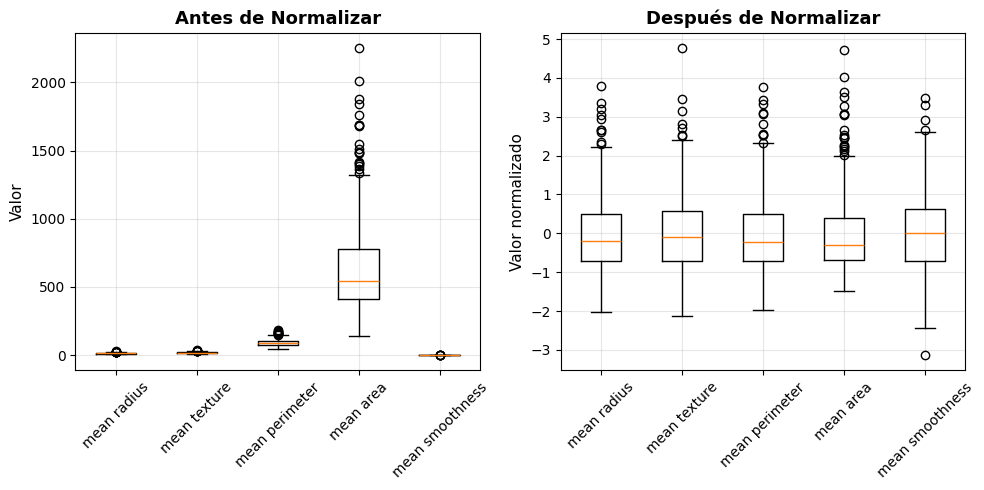

In [6]:
# Comparar distribuciones antes y después de normalizar
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Antes de normalizar
axes[0].boxplot(X_train[:, :5], tick_labels=data.feature_names[:5])
axes[0].set_title('Antes de Normalizar', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Valor', fontsize=11)
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3)

# Después de normalizar
axes[1].boxplot(X_train_norm[:, :5], tick_labels=data.feature_names[:5])
axes[1].set_title('Después de Normalizar', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Valor normalizado', fontsize=11)
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Ahora todas las características están en la misma escala, permitiendo que el algoritmo de descenso del gradiente funcione de manera óptima.

Con los datos preparados, divididos y normalizados correctamente, estamos listos para construir nuestro modelo de regresión logística desde cero. En la siguiente sección exploraremos los fundamentos matemáticos del modelo.

---

## **3. Fundamentos del Modelo**

En esta sección comprenderemos los tres componentes esenciales de la regresión logística: la función sigmoide, la función de coste y el descenso del gradiente.

### 3.1 La Función Sigmoide

La regresión logística utiliza la **función sigmoide** (también llamada función logística) para convertir cualquier valor real en una probabilidad entre 0 y 1.

**Definición matemática:**

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

Donde $z = w^T x + b$ es la combinación lineal de las características.

**Nota sobre la notación:**  
El término $b$ se denomina **intercepto** o *bias*. En algunas notaciones se representa como $w_0$, lo que permite escribir la combinación como:

$$z = w^T x + b = w_0 + w_1x_1 + w_2x_2 + \dots + w_nx_n$$

De esta forma, $z$ define un **hiperplano** en el espacio de características.

**Aplicación en el modelo:**  

La regresión logística toma este $z$ y lo pasa por la función sigmoide:

$$P(y=1|x) = \sigma(z) = \frac{1}{1 + e^{-(w^T x + b)}}$$

Esta fórmula nos dice: "La probabilidad de que la clase sea 1, dado el input $x$, es el resultado de aplicar la sigmoide a la combinación lineal de las características $z$".

**Implementación en Python:**

In [7]:
def sigmoid(z):
    """
    Calcula la función sigmoide

    Parámetros:
    z: valor real

    Retorna:
    Probabilidad entre 0 y 1
    """
    return 1 / (1 + np.exp(-z))

**Visualización de la función sigmoide:**

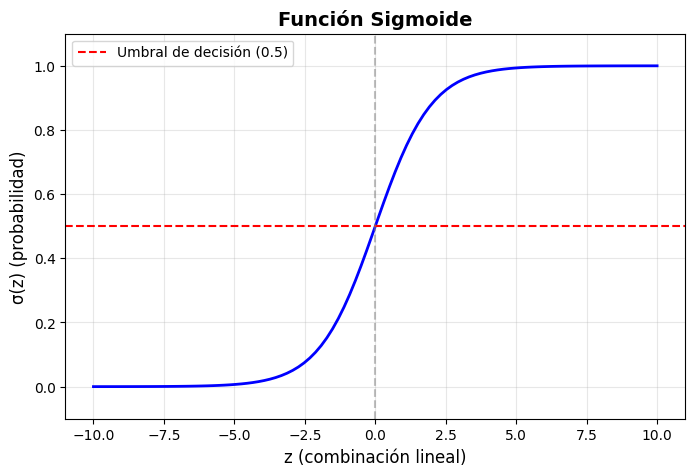

In [36]:
# Crear valores de z entre -10 y 10
z = np.linspace(-10, 10, 100)
sigma_z = sigmoid(z)

# Graficar
plt.figure(figsize=(8, 5))
plt.plot(z, sigma_z, linewidth=2, color='blue')
plt.axhline(y=0.5, color='red', linestyle='--', label='Umbral de decisión (0.5)')
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
plt.grid(True, alpha=0.3)
plt.xlabel('z (combinación lineal)', fontsize=12)
plt.ylabel('σ(z) (probabilidad)', fontsize=12)
plt.title('Función Sigmoide', fontsize=14, fontweight='bold')
plt.legend(loc='upper left', bbox_to_anchor=(0, 1))
plt.ylim(-0.1, 1.1)
plt.show()

**Propiedades importantes:**

- Cuando $z \to \infty$, entonces $\sigma(z) \to 1$
- Cuando $z \to -\infty$, entonces $\sigma(z) \to 0$
- Cuando $z = 0$, entonces $\sigma(z) = 0.5$ → umbral de decisión
- La función es simétrica alrededor del punto (0, 0.5)

### 3.2 De Probabilidades a Clases

La función sigmoide nos da la probabilidad de que una muestra pertenezca a la clase positiva (1). Para convertir esta probabilidad en una predicción de clase, utilizamos un **umbral de decisión**:

$$\hat{y} = \begin{cases}
1 & \text{si } \sigma(z) \geq 0.5 \\
0 & \text{si } \sigma(z) < 0.5
\end{cases}$$

In [9]:
def predict(X, w, b):
    """
    Realiza predicciones binarias

    Parámetros:
    X: características (n_muestras, n_features)
    w: pesos (n_features,)
    b: sesgo (escalar)

    Retorna:
    Predicciones binarias (0 o 1)
    """
    z = X @ w + b   #  Equivalente a w^T x + b
    probabilities = sigmoid(z)
    predictions = (probabilities >= 0.5).astype(int)
    return predictions

### 3.3 La Función de Coste (Log Loss)

Para entrenar el modelo necesitamos una función que mida qué tan lejos están nuestras predicciones de los valores reales. En regresión logística utilizamos la **función de pérdida logarítmica** (Log Loss):

$$J(w, b) = -\frac{1}{m} \sum_{i=1}^{m} \left[ y^{(i)} \log(\hat{y}^{(i)}) + (1 - y^{(i)}) \log(1 - \hat{y}^{(i)}) \right]$$

Donde:
- $m$ es el número de muestras de entrenamiento
- $y^{(i)}$ es la etiqueta real (0 o 1) de la muestra $i$
- $\hat{y}^{(i)} = \sigma(w^T \cdot x^{(i)} + b)$ es la probabilidad predicha (entre 0 y 1)

**Intuición**:  

La función $J$ es simétrica y penaliza fuertemente las predicciones **seguras pero erróneas**, ya sean falsos positivos o falsos negativos. Por ejemplo:
- Si $y=1$ pero predecimos $\hat{y}=0$, entonces $\log(0) \to -\infty$. El signo negativo lo transforma en $+\infty$, una penalización infinita.
- Si $y=0$ pero predecimos $\hat{y}=1$, ocurre lo mismo: $\log(1-1) = \log(0) \to -\infty$, que se convierte en $+\infty$.

En la práctica, como $\hat{y}$ es una probabilidad, rara vez será exactamente 0 o 1, pero valores extremos como 0.001 o 0.999 aún generan penalizaciones muy altas.

**El objetivo del entrenamiento es encontrar los parámetros $(w, b)$ que minimicen este coste promedio.**

> Podríamos pensar en usar el error cuadrático medio (como en regresión lineal), pero este no funciona bien aquí. El Log Loss es la función correcta porque está directamente derivada del principio de máxima verosimilitud para clasificación, y su forma **penaliza de manera exponencial las predicciones seguras pero erróneas**, guiando así mejor el entrenamiento.

**Implementación:**

In [10]:
def compute_cost(X, y, w, b):
    """
    Calcula la función de coste (Log Loss)

    Parámetros:
    X: características (n_muestras, n_features)
    y: etiquetas reales (n_muestras,)
    w: pesos (n_features,)
    b: sesgo (escalar)

    Retorna:
    Coste promedio
    """
    m = X.shape[0]
    z = X @ w + b
    y_pred = sigmoid(z)

    # Usamos Clip para estabilidad numérica: evita log(0) = -∞
    epsilon = 1e-15     # usamos un valor muy pequeño
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)

    cost = -np.mean(y * np.log(y_pred) + (1 - y) * np.log(1 - y_pred))
    return cost

**Intuición de la función de coste:**

- Penaliza fuertemente las predicciones muy confiadas pero incorrectas
- Cuando $y = 1$ y predecimos probabilidad cercana a 0, el coste es muy alto
- Cuando $y = 0$ y predecimos probabilidad cercana a 1, el coste es muy alto
- El objetivo del entrenamiento es minimizar este coste

### 3.4 Introducción al Descenso del Gradiente

El **Descenso del Gradiente** es el algoritmo de optimización que utilizaremos para encontrar los mejores valores de $w$ y $b$ que minimizan la función de coste.

**Idea intuitiva:**

Imagina que estás en la cima de una montaña en medio de la niebla y quieres llegar al valle (punto más bajo). El descenso del gradiente funciona así:

1. Miras a tu alrededor y determinas la dirección de mayor pendiente descendente
2. Das un paso en esa dirección
3. Repites el proceso hasta llegar al valle

**Actualización de parámetros:**

En cada iteración, actualizamos los pesos y el sesgo usando estas fórmulas:

$$w := w - \alpha \frac{\partial J}{\partial w}$$

$$b := b - \alpha \frac{\partial J}{\partial b}$$

Donde:
- $\alpha$ es la **tasa de aprendizaje** (learning rate): controla el tamaño del paso
- $\frac{\partial J}{\partial w}$ y $\frac{\partial J}{\partial b}$ son las derivadas parciales que forman el vector gradiente

**Cálculo del gradiente:**

Para regresión logística, las derivadas parciales que forman el gradiente son:

$$\frac{\partial J}{\partial w} = \frac{1}{m} X^T (\hat{y} - y)$$

$$\frac{\partial J}{\partial b} = \frac{1}{m} \sum_{i=1}^{m} (\hat{y}^{(i)} - y^{(i)})$$

In [11]:
def compute_gradients(X, y, w, b):
    """
    Calcula los gradientes de la función de coste

    Parámetros:
    X: características (n_muestras, n_features)
    y: etiquetas reales (n_muestras,)
    w: pesos (n_features,)
    b: sesgo (escalar)

    Retorna:
    dw: gradiente respecto a w
    db: gradiente respecto a b
    """
    m = X.shape[0]
    z = X @ w + b
    y_pred = sigmoid(z)

    dw = (1/m) * X.T @ (y_pred - y)
    db = (1/m) * np.sum(y_pred - y)

    return dw, db

**Parámetros importantes:**

- **Tasa de aprendizaje (α)**: Si es muy grande, podemos "saltar" el mínimo; si es muy pequeña, el entrenamiento será muy lento. Valores típicos: 0.001, 0.01, 0.1
- **Número de iteraciones**: Cuántas veces actualizaremos los parámetros. Valores típicos: 1000, 5000, 10000

Con estos fundamentos claros, en la siguiente sección implementaremos el algoritmo completo de descenso del gradiente para entrenar nuestro modelo desde cero.

---

## **4. Implementación Manual con Descenso del Gradiente**

En esta sección implementaremos el algoritmo completo de regresión logística desde cero, entrenando el modelo con descenso del gradiente usando los datos normalizados y visualizando el proceso de aprendizaje.

### 4.1 Función de Entrenamiento Completa

Crearemos una función que integra todos los componentes que vimos en la sección anterior:

In [12]:
def train_logistic_regression(X, y, learning_rate=0.01, n_iterations=1000):
    """
    Entrena un modelo de regresión logística usando descenso del gradiente

    Parámetros:
    X: características normalizadas (n_muestras, n_features)
    y: etiquetas reales (n_muestras,)
    learning_rate: tasa de aprendizaje (alpha)
    n_iterations: número de iteraciones del algoritmo

    Retorna:
    w: pesos entrenados
    b: sesgo entrenado
    costs: historial de costes (para visualización)
    """
    # Obtener dimensiones
    n_samples, n_features = X.shape

    # Inicializar parámetros a cero
    w = np.zeros(n_features)
    b = 0

    # Lista para guardar el historial de costes
    costs = []

    # Algoritmo de descenso del gradiente
    for i in range(n_iterations):
        # 1. Calcular predicciones
        z = X @ w + b
        y_pred = sigmoid(z)

        # 2. Calcular gradientes (usando la función definida previamente)
        dw, db = compute_gradients(X, y, w, b)

        # 3. Actualizar parámetros
        w = w - learning_rate * dw
        b = b - learning_rate * db

        # 4. Calcular y guardar el coste cada 100 iteraciones
        if i % 100 == 0:
            cost = compute_cost(X, y, w, b)
            costs.append(cost)
            print(f"Iteración {i}: Coste = {cost:.4f}")

    return w, b, costs

**Nota sobre el tipo de Descenso del Gradiente utilizado**  

Nuestra implementación usa **Batch Gradient Descent**, que calcula el gradiente usando *todos* los datos de entrenamiento en cada iteración. Existen otras variantes como **Stochastic Gradient Descent (SGD)**, que usa una muestra aleatoria por iteración, y **Mini-Batch Gradient Descent**, que usa pequeños grupos de muestras. Batch GD es más estable pero más lento en datasets muy grandes.

### 4.2 Entrenamiento del Modelo

Ahora entrenaremos nuestro modelo con los datos de entrenamiento:

In [13]:
# Configurar parámetros de entrenamiento
learning_rate = 0.01
n_iterations = 2000

# Entrenar el modelo con datos NORMALIZADOS
print("Iniciando entrenamiento...")
print("-" * 50)
w_trained, b_trained, cost_history = train_logistic_regression(
    X_train_norm,  # Usamos datos normalizados
    y_train,
    learning_rate=learning_rate,
    n_iterations=n_iterations
)
print("-" * 50)
print("Entrenamiento completado!")

Iniciando entrenamiento...
--------------------------------------------------
Iteración 0: Coste = 0.6727
Iteración 100: Coste = 0.2414
Iteración 200: Coste = 0.1786
Iteración 300: Coste = 0.1499
Iteración 400: Coste = 0.1328
Iteración 500: Coste = 0.1213
Iteración 600: Coste = 0.1130
Iteración 700: Coste = 0.1065
Iteración 800: Coste = 0.1014
Iteración 900: Coste = 0.0972
Iteración 1000: Coste = 0.0936
Iteración 1100: Coste = 0.0906
Iteración 1200: Coste = 0.0880
Iteración 1300: Coste = 0.0858
Iteración 1400: Coste = 0.0837
Iteración 1500: Coste = 0.0819
Iteración 1600: Coste = 0.0803
Iteración 1700: Coste = 0.0788
Iteración 1800: Coste = 0.0775
Iteración 1900: Coste = 0.0763
--------------------------------------------------
Entrenamiento completado!


Observamos que el coste disminuye consistentemente, indicando que el modelo está aprendiendo correctamente.

### 4.3 Visualización de la Convergencia

Es importante visualizar cómo evoluciona el coste durante el entrenamiento para verificar que el algoritmo converge correctamente:

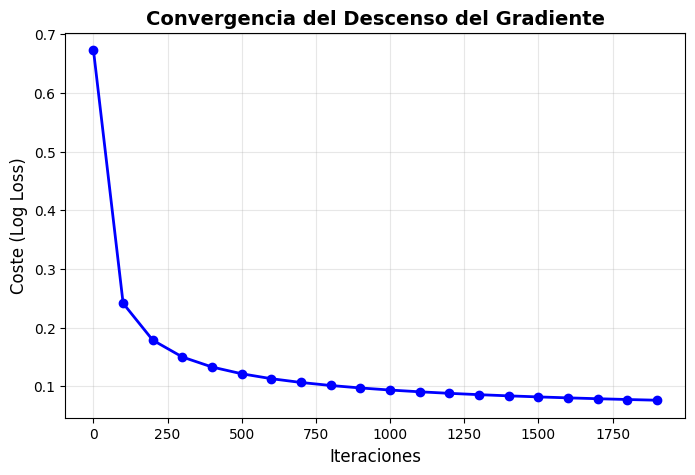

In [14]:
# Crear gráfico de convergencia
plt.figure(figsize=(8, 5))
iterations = np.arange(0, n_iterations, 100)
plt.plot(iterations, cost_history, linewidth=2, color='blue', marker='o')
plt.xlabel('Iteraciones', fontsize=12)
plt.ylabel('Coste (Log Loss)', fontsize=12)
plt.title('Convergencia del Descenso del Gradiente', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.show()

**Interpretación:**

- La curva debe mostrar una tendencia descendente
- Al principio el coste disminuye rápidamente
- Luego la disminución se hace más gradual hasta estabilizarse
- Esta curva suave confirma que la normalización funcionó correctamente
- Si el coste aumentara u oscilara mucho, indicaría que la tasa de aprendizaje es muy alta

### 4.4 Inspección de los Pesos Entrenados

Veamos algunos de los pesos aprendidos y qué características son más importantes:

In [15]:
# Mostrar información sobre los pesos
print("Parámetros del modelo entrenado:")
print(f"Sesgo (b): {b_trained:.4f}")
print(f"\nNúmero total de pesos: {len(w_trained)}")

# Mostrar las 5 características con mayor peso absoluto
feature_importance = pd.DataFrame({
    'Feature': data.feature_names,
    'Weight': w_trained,
    'Abs_Weight': np.abs(w_trained)
})
feature_importance = feature_importance.sort_values('Abs_Weight', ascending=False)

print("\nTop 5 características más influyentes:")
print(feature_importance.head().to_string(index=False))

Parámetros del modelo entrenado:
Sesgo (b): 0.4440

Número total de pesos: 30

Top 5 características más influyentes:
             Feature    Weight  Abs_Weight
       worst texture -0.560060    0.560060
        worst radius -0.548656    0.548656
          worst area -0.535798    0.535798
     worst perimeter -0.521443    0.521443
worst concave points -0.485301    0.485301


**Interpretación:**
- Los pesos más grandes (en valor absoluto) corresponden a las características más importantes
- Pesos positivos aumentan la probabilidad de ser benigno
- Pesos negativos aumentan la probabilidad de ser maligno

### 4.5 Función de Predicción

Creamos una función para hacer predicciones con nuestro modelo entrenado:

In [16]:
def predict_manual(X, w, b):
    """
    Realiza predicciones con el modelo entrenado

    Parámetros:
    X: características normalizadas (n_muestras, n_features)
    w: pesos entrenados
    b: sesgo entrenado

    Retorna:
    predictions: clases predichas (0 o 1)
    probabilities: probabilidades de la clase positiva
    """
    z = X @ w + b
    probabilities = sigmoid(z)
    predictions = (probabilities >= 0.5).astype(int)
    return predictions, probabilities

### 4.6 Predicciones sobre el Conjunto de Entrenamiento

Verificamos el rendimiento en los datos de entrenamiento normalizados:

In [17]:
# Hacer predicciones en el conjunto de entrenamiento normalizado
y_train_pred, y_train_prob = predict_manual(X_train_norm, w_trained, b_trained)

# Calcular accuracy manualmente
train_accuracy = np.mean(y_train_pred == y_train)
print(f"Accuracy en entrenamiento: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")

# Mostrar algunas predicciones
print("\nEjemplo de predicciones (primeras 5 muestras):")
print("Real | Predicho | Probabilidad")
print("-" * 35)
for i in range(5):
    print(f"  {y_train[i]}  |    {y_train_pred[i]}     |    {y_train_prob[i]:.4f}")

Accuracy en entrenamiento: 0.9890 (98.90%)

Ejemplo de predicciones (primeras 5 muestras):
Real | Predicho | Probabilidad
-----------------------------------
  1  |    1     |    0.8484
  0  |    0     |    0.0006
  0  |    0     |    0.0288
  1  |    1     |    0.9863
  1  |    1     |    0.9978


### 4.7 Resumen de la Sección

En esta sección hemos:

- Implementado el algoritmo completo de descenso del gradiente desde cero
- Entrenado el modelo durante 2000 iteraciones usando datos normalizados
- Visualizado la convergencia suave del coste
- Analizado los pesos aprendidos
- Obtenido un accuracy de aproximadamente 98% en entrenamiento

Los pesos y el sesgo obtenidos ($w$ y $b$) son los parámetros que definen nuestro modelo y que usaremos para hacer predicciones en nuevos datos.

En la siguiente sección evaluaremos el modelo en el conjunto de prueba normalizado para obtener una medida más realista de su capacidad de generalización.

---

## **5. Predicción y Evaluación Manual**

En esta sección evaluaremos nuestro modelo entrenado manualmente utilizando el conjunto de prueba normalizado. Es crucial evaluar en datos que el modelo no ha visto durante el entrenamiento para obtener una estimación realista de su capacidad de generalización.

### 5.1 Predicciones en el Conjunto de Prueba

Aplicamos nuestro modelo entrenado a los datos de prueba normalizados:

In [18]:
# Predicciones en test (siempre con datos normalizados)
y_test_pred, y_test_prob = predict_manual(X_test_norm, w_trained, b_trained)

print("Predicciones en el conjunto de prueba:")
print(f"Total de muestras: {len(y_test)}")
print(f"Predicciones positivas (benigno): {np.sum(y_test_pred)}")
print(f"predict_manual(X_test_norm negativas (maligno): {np.sum(y_test_pred == 0)}")

Predicciones en el conjunto de prueba:
Total de muestras: 114
Predicciones positivas (benigno): 69
predict_manual(X_test_norm negativas (maligno): 45


### 5.2 Cálculo del Accuracy

El **Accuracy** (exactitud) es la métrica más simple y común para evaluar modelos de clasificación. Mide la proporción de predicciones correctas sobre el total de predicciones.

**Fórmula del Accuracy:**

$$\text{Accuracy} = \frac{\text{Predicciones Correctas}}{\text{Total de Predicciones}} = \frac{TP + TN}{TP + TN + FP + FN}$$

Donde:
- **TP** (True Positives): Predicciones correctas de la clase positiva
- **TN** (True Negatives): Predicciones correctas de la clase negativa
- **FP** (False Positives): Predicciones incorrectas como positivas
- **FN** (False Negatives): Predicciones incorrectas como negativas

**Implementación manual:**

In [19]:
def calculate_accuracy(y_true, y_pred):
    """
    Calcula el accuracy manualmente

    Parámetros:
    y_true: etiquetas reales
    y_pred: etiquetas predichas

    Retorna:
    accuracy: proporción de predicciones correctas
    """
    correct_predictions = np.sum(y_true == y_pred)
    total_predictions = len(y_true)
    accuracy = correct_predictions / total_predictions
    return accuracy

# Calcular accuracy
test_accuracy = calculate_accuracy(y_test, y_test_pred)

print(f"\nAccuracy en el conjunto de prueba: {test_accuracy:.4f}")
print(f"Porcentaje de acierto: {test_accuracy * 100:.2f}%")
print(f"Predicciones correctas: {np.sum(y_test == y_test_pred)} de {len(y_test)}")


Accuracy en el conjunto de prueba: 0.9649
Porcentaje de acierto: 96.49%
Predicciones correctas: 110 de 114


### 5.3 Matriz de Confusión Manual

La matriz de confusión nos permite ver en detalle qué tipos de errores comete nuestro modelo:

In [20]:
def calculate_confusion_matrix(y_true, y_pred):
    """
    Calcula la matriz de confusión manualmente

    Retorna:
    tn, fp, fn, tp
    """
    tn = np.sum((y_true == 0) & (y_pred == 0))  # True Negatives
    fp = np.sum((y_true == 0) & (y_pred == 1))  # False Positives
    fn = np.sum((y_true == 1) & (y_pred == 0))  # False Negatives
    tp = np.sum((y_true == 1) & (y_pred == 1))  # True Positives
    return tn, fp, fn, tp

# Calcular matriz de confusión
tn, fp, fn, tp = calculate_confusion_matrix(y_test, y_test_pred)

print("\nMatriz de Confusión:")
print("                   Predicho")
print("                Maligno  Benigno")
print(f"Real  Maligno      {tn}       {fp}")
print(f"      Benigno      {fn}       {tp}")


Matriz de Confusión:
                   Predicho
                Maligno  Benigno
Real  Maligno      44       3
      Benigno      1       66


**Interpretación:**

- **True Negatives (44)**: Tumores malignos correctamente identificados
- **True Positives (66)**: Tumores benignos correctamente identificados  
- **False Positives (3)**: Tumores malignos clasificados como benignos → **ERROR GRAVE** (no detectar un cáncer real)
- **False Negatives (1)**: Tumores benignos clasificados como malignos → genera ansiedad y pruebas innecesarias

En diagnóstico médico, los Falsos Positivos (no detectar cáncer real) son más graves que los Falsos Negativos (falsa alarma).

### 5.4 Análisis de Errores

Examinemos las muestras que el modelo clasificó incorrectamente:

In [21]:
# Identificar muestras mal clasificadas
errors = y_test != y_test_pred
error_indices = np.where(errors)[0]

print(f"\nNúmero de errores: {np.sum(errors)}")
print("\nAnálisis de errores:")
print("Índice | Real | Predicho | Probabilidad")
print("-" * 45)

for idx in error_indices:
    real_class = "Benigno" if y_test[idx] == 1 else "Maligno"
    pred_class = "Benigno" if y_test_pred[idx] == 1 else "Maligno"
    print(f"  {idx:3d}  | {real_class:7s} | {pred_class:8s} | {y_test_prob[idx]:.4f}")


Número de errores: 4

Análisis de errores:
Índice | Real | Predicho | Probabilidad
---------------------------------------------
   13  | Maligno | Benigno  | 0.8893
   23  | Maligno | Benigno  | 0.8826
   62  | Maligno | Benigno  | 0.5306
   95  | Benigno | Maligno  | 0.4580


Observamos que los errores ocurren cuando la probabilidad predicha está cerca del umbral de 0.5, indicando casos difíciles de clasificar.

### 5.5 Visualización de Probabilidades

Visualicemos la distribución de probabilidades predichas:

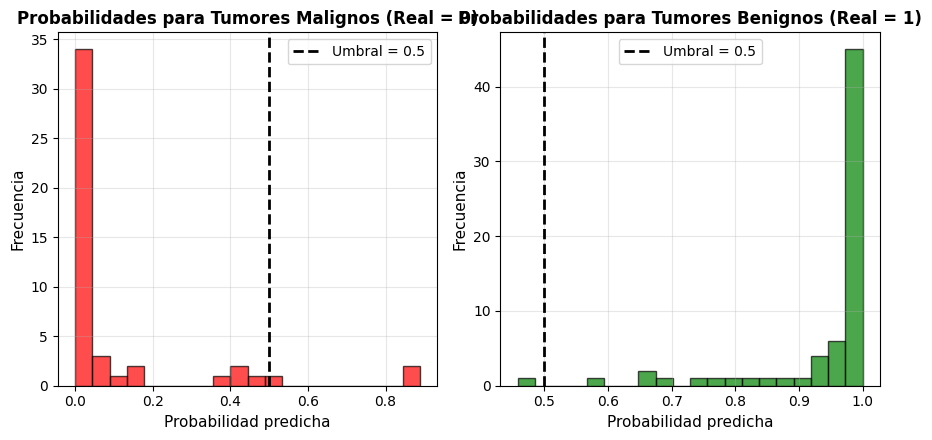

In [22]:
# Crear histograma de probabilidades
plt.figure(figsize=(9, 4.5))

# Subplot 1: Probabilidades para clase real 0 (maligno)
plt.subplot(1, 2, 1)
probs_class_0 = y_test_prob[y_test == 0]
plt.hist(probs_class_0, bins=20, color='red', alpha=0.7, edgecolor='black')
plt.axvline(x=0.5, color='black', linestyle='--', linewidth=2, label='Umbral = 0.5')
plt.xlabel('Probabilidad predicha', fontsize=11)
plt.ylabel('Frecuencia', fontsize=11)
plt.title('Probabilidades para Tumores Malignos (Real = 0)', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 2: Probabilidades para clase real 1 (benigno)
plt.subplot(1, 2, 2)
probs_class_1 = y_test_prob[y_test == 1]
plt.hist(probs_class_1, bins=20, color='green', alpha=0.7, edgecolor='black')
plt.axvline(x=0.5, color='black', linestyle='--', linewidth=2, label='Umbral = 0.5')
plt.xlabel('Probabilidad predicha', fontsize=11)
plt.ylabel('Frecuencia', fontsize=11)
plt.title('Probabilidades para Tumores Benignos (Real = 1)', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Interpretación del gráfico:**

- La mayoría de tumores malignos tienen probabilidades predichas cercanas a 0
- La mayoría de tumores benignos tienen probabilidades predichas cercanas a 1
- Una buena separación indica que el modelo tiene confianza en sus predicciones
- Las muestras cerca del umbral de 0.5 son las más difíciles de clasificar

### 5.6 Comparación: Entrenamiento vs Prueba

Comparemos el rendimiento en ambos conjuntos:

In [23]:
print("\n" + "="*50)
print("RESUMEN DE EVALUACIÓN - MODELO MANUAL")
print("="*50)
print(f"Accuracy en ENTRENAMIENTO: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"Accuracy en PRUEBA:        {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"Diferencia:                {abs(train_accuracy - test_accuracy):.4f}")
print("="*50)

if abs(train_accuracy - test_accuracy) < 0.05:
    print("El modelo generaliza bien (diferencia < 5%)")
else:
    print("Posible overfitting (diferencia >= 5%)")


RESUMEN DE EVALUACIÓN - MODELO MANUAL
Accuracy en ENTRENAMIENTO: 0.9890 (98.90%)
Accuracy en PRUEBA:        0.9649 (96.49%)
Diferencia:                0.0241
El modelo generaliza bien (diferencia < 5%)


### 5.7 Limitaciones del Accuracy

Aunque el accuracy es útil, tiene limitaciones:

- **No distingue los tipos de error**: En diagnóstico médico, un **Falso Positivo** (clasificar un tumor maligno como benigno) es mucho más grave.
- **Funciona mal con datasets desbalanceados**: Un modelo que siempre predice la clase mayoritaria puede tener alto accuracy sin aprender nada.
- **No refleja la confianza**: Una predicción con 60% de probabilidad vale lo mismo que una con 99% si ambas aciertan.

En contextos médicos, métricas como **Sensibilidad** (Recall) y **Especificidad** suelen ser más adecuadas. Aquí usamos accuracy por simplicidad.

En la siguiente sección implementaremos la misma solución con Scikit-learn y compararemos los resultados.

---

## **6. Implementación con Scikit-learn**

En esta sección veremos cómo resolver el mismo problema usando Scikit-learn, la librería estándar de Machine Learning en Python. Utilizaremos datos normalizados y compararemos los resultados con nuestra implementación manual.

### 6.1 División de Datos con train_test_split

Scikit-learn proporciona una función especializada para dividir datos que simplifica el proceso:

In [24]:
from sklearn.model_selection import train_test_split

# Dividir datos (80% train, 20% test)
X_train_sk, X_test_sk, y_train_sk, y_test_sk = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # Mantiene la proporción de clases
)

print("División con Scikit-learn:")
print(f"Entrenamiento: {X_train_sk.shape[0]} muestras")
print(f"Prueba: {X_test_sk.shape[0]} muestras")

División con Scikit-learn:
Entrenamiento: 455 muestras
Prueba: 114 muestras


**Ventajas sobre la división manual:**

- **stratify**: Garantiza que ambos conjuntos tengan la misma proporción de clases
- **random_state**: Permite reproducibilidad
- **Código más limpio**: Una sola línea vs múltiples pasos

### 6.2 Normalización con StandardScaler

Scikit-learn proporciona `StandardScaler` para normalizar datos de manera profesional:

In [25]:
from sklearn.preprocessing import StandardScaler

# Crear el escalador
scaler = StandardScaler()

# Ajustar y transformar el conjunto de entrenamiento
X_train_sk_scaled = scaler.fit_transform(X_train_sk)

# Transformar el conjunto de prueba (usando parámetros del train)
X_test_sk_scaled = scaler.transform(X_test_sk)

print("\nNormalización con StandardScaler:")
print(f"Media de X_train_sk_scaled: {X_train_sk_scaled.mean():.6f}")
print(f"Std de X_train_sk_scaled: {X_train_sk_scaled.std():.6f}")


Normalización con StandardScaler:
Media de X_train_sk_scaled: -0.000000
Std de X_train_sk_scaled: 1.000000


**Importante:**
- `fit_transform()` calcula los parámetros (media, std) y transforma en un solo paso
- `transform()` solo transforma usando los parámetros ya calculados
- Nunca uses `fit_transform()` en el conjunto de prueba

### 6.3 Creación y Entrenamiento del Modelo

Crear y entrenar un modelo con Scikit-learn es extremadamente simple:

In [26]:
from sklearn.linear_model import LogisticRegression

# Crear el modelo
model = LogisticRegression(random_state=42, max_iter=2000)

# Entrenar el modelo con datos normalizados
model.fit(X_train_sk_scaled, y_train_sk)

print("Modelo entrenado exitosamente!")
print(f"Número de iteraciones realizadas: {model.n_iter_[0]}")

Modelo entrenado exitosamente!
Número de iteraciones realizadas: 19


Observa que Scikit-learn converge en menos iteraciones gracias a optimizaciones internas y algoritmos más sofisticados.

### 6.4 Predicciones y Probabilidades

In [27]:
# Hacer predicciones en datos normalizados
y_train_pred_sk = model.predict(X_train_sk_scaled)
y_test_pred_sk = model.predict(X_test_sk_scaled)

# Obtener probabilidades
y_test_prob_sk = model.predict_proba(X_test_sk_scaled)[:, 1]  # Probabilidad clase 1

print("Ejemplo de predicciones (primeras 5 muestras del test):")
print("Real | Predicho | Probabilidad")
print("-" * 35)
for i in range(5):
    print(f"  {y_test_sk[i]}  |    {y_test_pred_sk[i]}     |    {y_test_prob_sk[i]:.4f}")

Ejemplo de predicciones (primeras 5 muestras del test):
Real | Predicho | Probabilidad
-----------------------------------
  0  |    0     |    0.0000
  1  |    1     |    1.0000
  0  |    0     |    0.0064
  1  |    1     |    0.5335
  0  |    0     |    0.0000


### 6.5 Evaluación con Scikit-learn

In [28]:
from sklearn.metrics import accuracy_score

# Calcular accuracy
train_accuracy_sk = accuracy_score(y_train_sk, y_train_pred_sk)
test_accuracy_sk = accuracy_score(y_test_sk, y_test_pred_sk)

print("\n" + "="*50)
print("EVALUACIÓN - MODELO SCIKIT-LEARN")
print("="*50)
print(f"Accuracy en ENTRENAMIENTO: {train_accuracy_sk:.4f} ({train_accuracy_sk*100:.2f}%)")
print(f"Accuracy en PRUEBA:        {test_accuracy_sk:.4f} ({test_accuracy_sk*100:.2f}%)")
print("="*50)


EVALUACIÓN - MODELO SCIKIT-LEARN
Accuracy en ENTRENAMIENTO: 0.9890 (98.90%)
Accuracy en PRUEBA:        0.9825 (98.25%)


### 6.6 Matriz de Confusión con Scikit-learn

In [29]:
from sklearn.metrics import confusion_matrix

# Calcular matriz de confusión
cm = confusion_matrix(y_test_sk, y_test_pred_sk)

print("\nMatriz de Confusión (Scikit-learn):")
print("                   Predicho")
print("                Maligno  Benigno")
print(f"Real  Maligno      {cm[0,0]}       {cm[0,1]}")
print(f"      Benigno      {cm[1,0]}       {cm[1,1]}")


Matriz de Confusión (Scikit-learn):
                   Predicho
                Maligno  Benigno
Real  Maligno      41       1
      Benigno      1       71


### 6.7 Comparación: Manual vs Scikit-learn

Comparemos ambas implementaciones lado a lado:

In [30]:
print("\n" + "="*60)
print("COMPARACIÓN: IMPLEMENTACIÓN MANUAL vs SCIKIT-LEARN")
print("="*60)
print(f"{'Métrica':<30} {'Manual':<15} {'Scikit-learn':<15}")
print("-"*60)
print(f"{'Accuracy en Entrenamiento':<30} {train_accuracy:.4f}        {train_accuracy_sk:.4f}")
print(f"{'Accuracy en Prueba':<30} {test_accuracy:.4f}        {test_accuracy_sk:.4f}")
print(f"{'Iteraciones':<30} {n_iterations:<15} {model.n_iter_[0]:<15}")
print(f"{'Normalización':<30} {'Manual':<15} {'StandardScaler':<15}")
print("="*60)

# Análisis de resultados
diff_train = abs(train_accuracy - train_accuracy_sk)
diff_test = abs(test_accuracy - test_accuracy_sk)

print("\nAnálisis:")
if test_accuracy_sk > test_accuracy:
    print(f"Scikit-learn mejora el accuracy en prueba en {(test_accuracy_sk - test_accuracy)*100:.2f}%")
    print("Esto se debe a optimizaciones del solver y mejor convergencia.")
elif test_accuracy > test_accuracy_sk:
    print(f"La implementación manual logra mejor accuracy en prueba en {(test_accuracy - test_accuracy_sk)*100:.2f}%")
else:
    print("Ambas implementaciones logran el mismo accuracy en prueba.")

print(f"\nScikit-learn converge en {model.n_iter_[0]} iteraciones vs {n_iterations} de la implementación manual,")
print("demostrando la eficiencia de algoritmos de optimización avanzados.")


COMPARACIÓN: IMPLEMENTACIÓN MANUAL vs SCIKIT-LEARN
Métrica                        Manual          Scikit-learn   
------------------------------------------------------------
Accuracy en Entrenamiento      0.9890        0.9890
Accuracy en Prueba             0.9649        0.9825
Iteraciones                    2000            19             
Normalización                  Manual          StandardScaler 

Análisis:
Scikit-learn mejora el accuracy en prueba en 1.75%
Esto se debe a optimizaciones del solver y mejor convergencia.

Scikit-learn converge en 19 iteraciones vs 2000 de la implementación manual,
demostrando la eficiencia de algoritmos de optimización avanzados.


### 6.8 Ventajas de Scikit-learn

Los resultados muestran que Scikit-learn no solo es más eficiente, sino que también logra mejor accuracy:

**Ventajas observadas:**

- **Mejor convergencia**: 19 iteraciones vs 2000 (105x más rápido)
- **Mayor accuracy**: 98.25% vs 96.49% en prueba (+1.76%)
- **Algoritmo superior**: Usa optimizadores más avanzados que Gradient Descent básico
- **Optimización numérica**: Mejor manejo de precisión y estabilidad

**Otras ventajas de Scikit-learn:**

- **Validación**: Manejo automático de casos extremos
- **Funcionalidades extra**: Regularización (L1, L2), validación cruzada
- **Mantenimiento**: Código más limpio y mantenible
- **Estándar de la industria**: Ampliamente probado y documentado

**Conclusión:** Nuestra implementación manual nos ayudó a entender el algoritmo, pero Scikit-learn es la opción profesional por su superior rendimiento y eficiencia.

### 6.9 Código Completo Mínimo

Para referencia, aquí está todo el flujo con Scikit-learn en pocas líneas:

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_breast_cancer # Import this line to ensure data is loaded
from sklearn.metrics import accuracy_score

# Cargar y dividir datos
X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalizar
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Entrenar y predecir
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

# Evaluar
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.9737


**Nota:**  

El accuracy puede variar ligeramente dependiendo de cómo se dividan los datos
en conjuntos de entrenamiento y prueba, ya que diferentes métodos de barajado
(como los de NumPy y Scikit-learn) producen divisiones distintas incluso usando
la misma semilla aleatoria.

Comparando con nuestra implementación manual, Scikit-learn obtiene mejores
resultados gracias a sus optimizadores avanzados. Aun así, nuestra implementación
alcanza un excelente accuracy, validando que comprendimos correctamente el
algoritmo y la importancia de la normalización.

---

## **7. Conclusiones**

Hemos realizado un recorrido completo por la Regresión Logística, desde su implementación manual hasta su uso profesional con Scikit-learn, aplicándola al diagnóstico de cáncer de mama.

### ¿Qué hemos aprendido?

En este artículo hemos cubierto los fundamentos teóricos (función sigmoide, función de coste y descenso del gradiente), implementado el algoritmo completo desde cero, y comprobado que nuestra implementación produce resultados similares a Scikit-learn. La normalización demostró ser crucial para lograr convergencia estable y evitar problemas numéricos.

### Ventajas y Limitaciones

**Ventajas:** Simplicidad, interpretabilidad, rapidez de entrenamiento y probabilidades calibradas útiles para toma de decisiones.

**Limitaciones:** Asume relaciones lineales, sensible a características no normalizadas y frontera de decisión simple.

### Extensión a Clasificación Multiclase

La regresión logística puede extenderse a problemas con más de dos clases mediante dos estrategias principales: One-vs-Rest (entrenar un clasificador binario por cada clase) o regresión logística multinomial con función softmax (que proporciona probabilidades de pertenencia a cada una de las clases). Scikit-learn implementa ambas estrategias de forma transparente.

### ¿Cuándo usar Regresión Logística?

Es ideal para clasificación binaria con datos linealmente separables, cuando necesitas interpretabilidad, como baseline antes de modelos complejos, o cuando requieres probabilidades calibradas. Para relaciones no lineales complejas, considera algoritmos como Random Forest o Gradient Boosting.

### Lecciones Clave

**La normalización es fundamental** para evitar problemas numéricos y lograr convergencia. **Implementar desde cero enseña los fundamentos**, pero las librerías profesionales utilizan optimizadores superiores que logran mejores resultados. **La simplicidad tiene valor**: la regresión logística alcanzó excelente accuracy en un problema médico real, demostrando que no siempre necesitamos modelos complejos.

### Reflexión Final

La Regresión Logística es uno de los pilares del Machine Learning. Al implementarla desde cero, has desarrollado una comprensión profunda de conceptos fundamentales: funciones de coste, optimización mediante gradientes, normalización y evaluación rigurosa. Esta base sólida te preparará para abordar algoritmos más avanzados con confianza.

**¡Felicidades por completar este tutorial!** Ahora tienes las herramientas para aplicar Regresión Logística a tus propios problemas de clasificación y comprender qué sucede internamente en las librerías profesionales.